In [9]:
# import libraries
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import sys
import seaborn as sns
PROJECT_ROOT = os.path.abspath("..")
sys.path.insert(0, PROJECT_ROOT)
from src.data.load_data import load_raw_data, encode_target
from src.data.clean_data import report_unknown_categories

In [5]:
data = encode_target(load_raw_data('../data/raw/bank-full.csv'))
print(data.head())
print(f'{data.shape[0]} rows and {data.shape[1]} columns')

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome  y  
0  unknown    5   may       261         1     -1         0  unknown  0  
1  unknown    5   may       151         1     -1         0  unknown  0  
2  unknown    5   may        76         1     -1         0  unknown  0  
3  unknown    5   may        92         1     -1         0  unknown  0  
4  unknown    5   may       198         1     -1         0  unknown  0  
45211 rows and 17 columns


In [6]:
# quality checks
report_unknown_categories(data)
print('Data quality checks completed successfully.')

Data quality checks completed successfully.


In [7]:
print("Duplicate rows: ", data.duplicated().sum())
print("Missing values: ", data.isnull().sum().sum())
print("Data types: ", data.dtypes)
print("Summary statistics: ", data.describe())
print("Target variable distribution: ", data['y'].value_counts(normalize=True))

Duplicate rows:  0
Missing values:  0
Data types:  age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y             int64
dtype: object
Summary statistics:                  age        balance           day      duration      campaign  \
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210    1362.272058     15.806419    258.163080      2.763841   
std       10.618762    3044.765829      8.322476    257.527812      3.098021   
min       18.000000   -8019.000000      1.000000      0.000000      1.000000   
25%       33.000000      72.000000      8.000000    103.000000      1.000000   
50%       39.000000     448.000000     16.000000    180.000000      2.000000   
75%       48.0

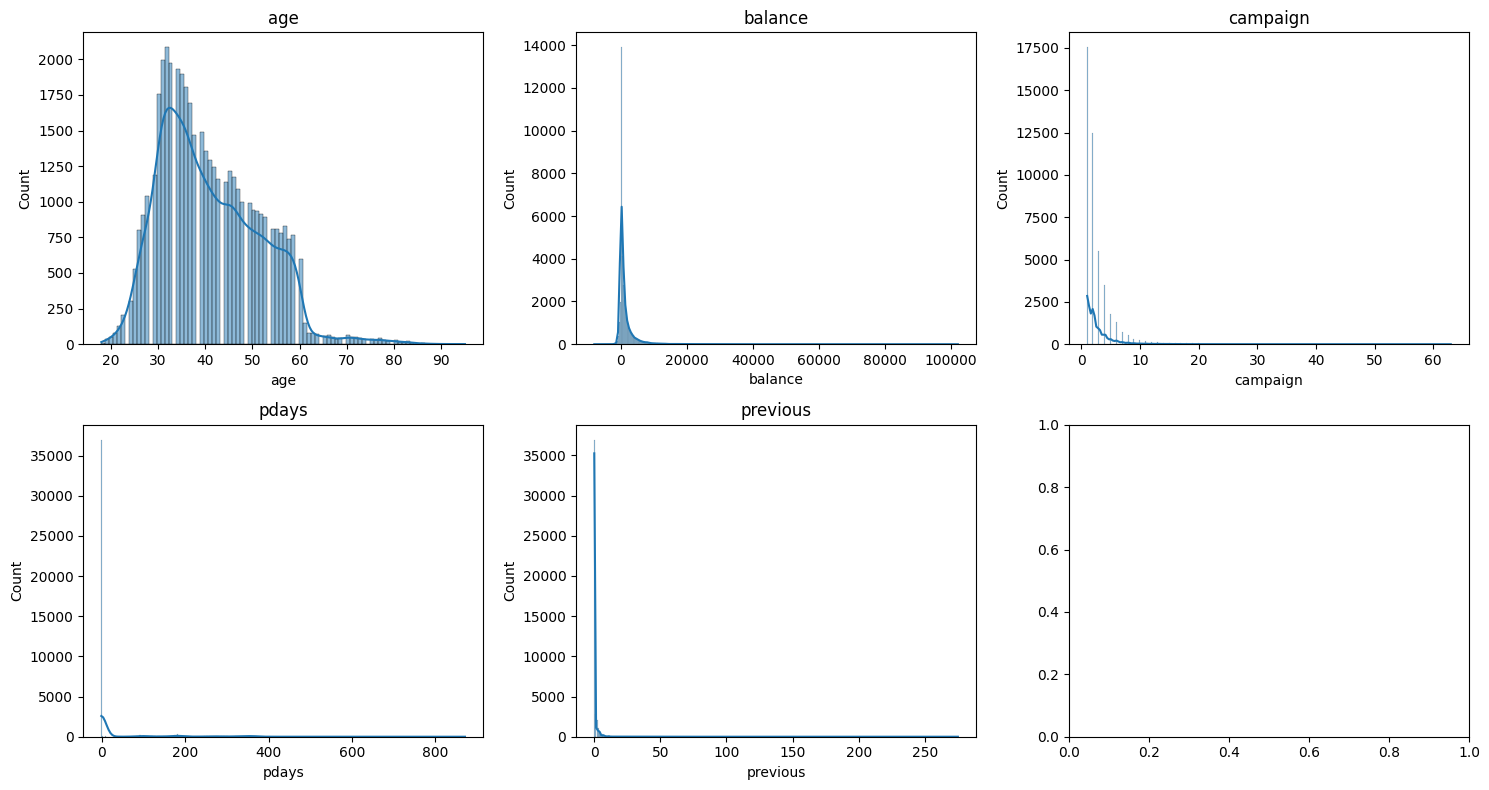

In [10]:
# Univariate: numeric feature distributions
numeric_cols = ['age', 'balance', 'campaign', 'pdays', 'previous']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(data[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

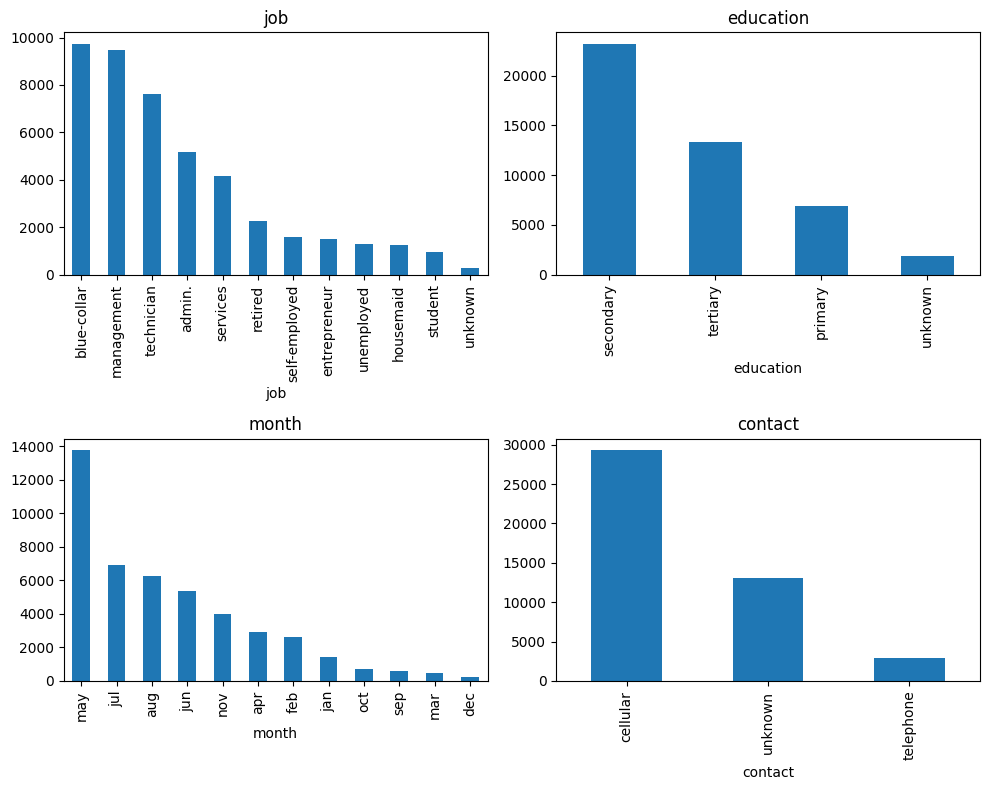

In [11]:
# Univariate: categorical frequency
categorical_cols = ['job', 'education', 'month', 'contact']
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.flat, categorical_cols):
    data[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [12]:
# Bivariate: subscription rate by job / education / month
# seasonality
for col in ['job', 'education', 'month']:
    print(f"Subscription rate by {col}:")
    print(data.groupby(col)['y'].mean().sort_values(ascending=False))

Subscription rate by job:
job
student          0.286780
retired          0.227915
unemployed       0.155027
management       0.137556
admin.           0.122027
self-employed    0.118429
unknown          0.118056
technician       0.110570
services         0.088830
housemaid        0.087903
entrepreneur     0.082717
blue-collar      0.072750
Name: y, dtype: float64
Subscription rate by education:
education
tertiary     0.150064
unknown      0.135703
secondary    0.105594
primary      0.086265
Name: y, dtype: float64
Subscription rate by month:
month
mar    0.519916
dec    0.467290
sep    0.464594
oct    0.437669
apr    0.196794
feb    0.166478
aug    0.110133
jun    0.102228
nov    0.101511
jan    0.101212
jul    0.090935
may    0.067195
Name: y, dtype: float64


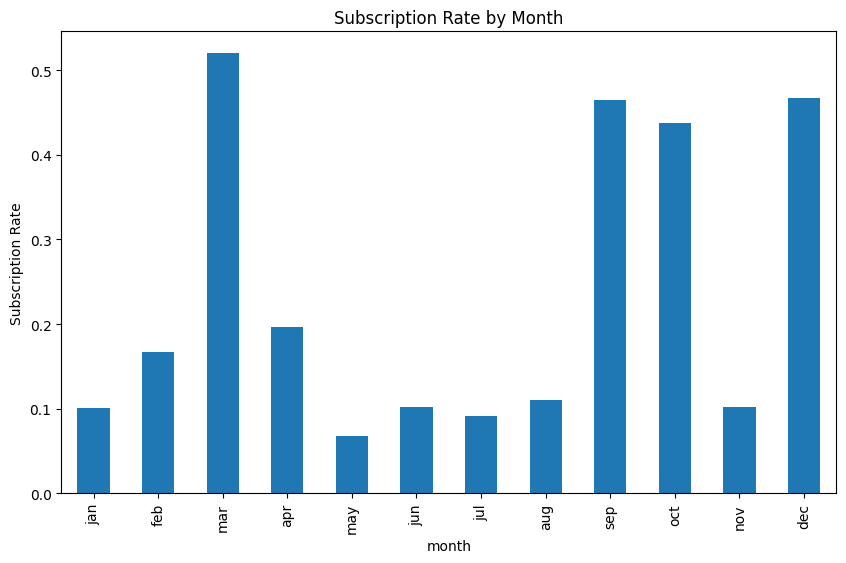

In [13]:
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
rate_by_month = data.groupby('month')['y'].mean().reindex(month_order)
rate_by_month.plot(kind='bar', figsize=(10, 6), title='Subscription Rate by Month')
plt.ylabel('Subscription Rate')
plt.show()

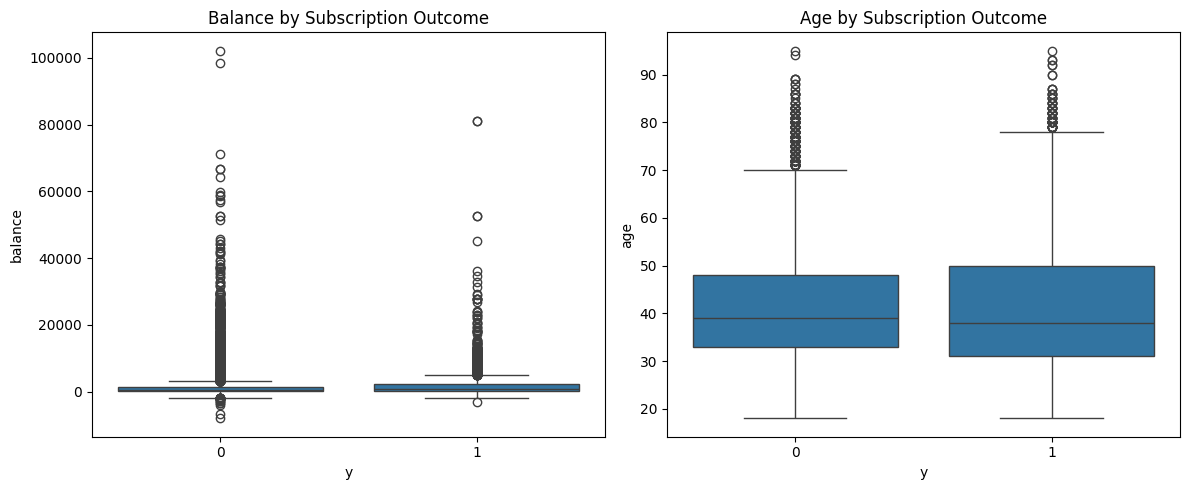

In [14]:
# Bivariate: balance / age by subscription outcome
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x='y', y='balance', data=data, ax=axes[0])
sns.boxplot(x='y', y='age', data=data, ax=axes[1])
axes[0].set_title('Balance by Subscription Outcome')
axes[1].set_title('Age by Subscription Outcome')
plt.tight_layout()
plt.show()

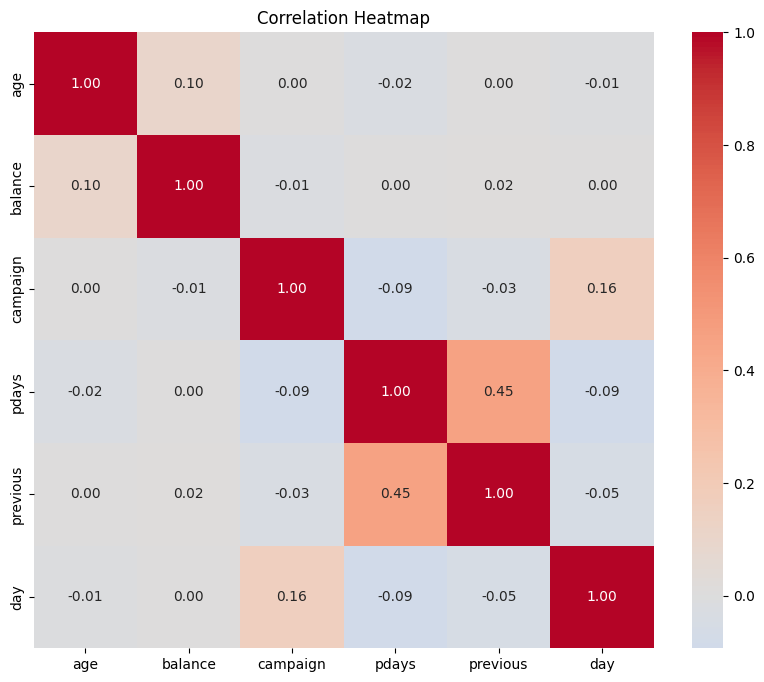

In [15]:
# Multivariate: correlation heatmap
corr = data[['age', 'balance', 'campaign', 'pdays', 'previous', 'day']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title('Correlation Heatmap')
plt.show()

In [17]:
# Outlier scan (IQR rule)
for col in ['balance', 'campaign']:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((data[col] < lower_bound) | (data[col] > upper_bound)).sum()
    print(f"{col}: {outliers} outliers detected. rows outside [{lower_bound}, {upper_bound}]")

balance: 4729 outliers detected. rows outside [-1962.0, 3462.0]
campaign: 3064 outliers detected. rows outside [-2.0, 6.0]
